# classification problem

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score,log_loss,r2_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression,LinearRegression,ElasticNet
from sklearn.ensemble import BaggingRegressor,RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from tqdm import tqdm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [18]:
cancer=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Wisconsin\\BreastCancer.csv")
cancer

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
694,1369821,10,10,10,10,5,10,10,10,7,Malignant
695,1371026,5,10,10,10,4,10,5,6,3,Malignant
696,1371920,5,1,1,1,2,1,3,2,1,Benign
697,8233704,4,1,1,1,1,1,2,1,1,Benign


In [25]:
X,y=cancer.drop("Class",axis=1),cancer["Class"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26,stratify=cancer["Class"])

In [26]:
features=[2,3,4,5,6,7]
scores=[]
for f in tqdm(features):
    for n in [25,50,75,100,125]:
        rf=RandomForestClassifier(random_state=26,max_features=f,n_estimators=n)
        rf.fit(X_train,y_train)
        y_pred_prob=rf.predict_proba(X_test)
        scores.append([f,n,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["Model","n_est","score"])
df_scores.sort_values("score")
       

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.40it/s]


,Model,n_est,score
0,2,25,0.094429
4,2,125,0.096572
20,6,25,0.097490
3,2,100,0.099016
2,2,75,0.100390
13,4,100,0.101395
12,4,75,0.101769
14,4,125,0.101883
18,5,100,0.102449
19,5,125,0.102550


In [27]:
bm=RandomForestClassifier(random_state=26,max_features=6,n_estimators=25)
bm.fit(X_train,y_train)
y_pred_prob=bm.predict_proba(X_test)
y_pred=bm.predict(X_test)
y_pred


array(['Benign', 'Benign', 'Benign', 'Benign', 'Malignant', 'Malignant',
       'Benign', 'Benign', 'Benign', 'Benign', 'Malignant', 'Malignant',
       'Benign', 'Malignant', 'Malignant', 'Benign', 'Benign', 'Benign',
       'Malignant', 'Malignant', 'Benign', 'Benign', 'Benign', 'Benign',
       'Malignant', 'Benign', 'Benign', 'Benign', 'Malignant',
       'Malignant', 'Benign', 'Benign', 'Benign', 'Malignant', 'Benign',
       'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign',
       'Benign', 'Benign', 'Benign', 'Benign', 'Malignant', 'Malignant',
       'Malignant', 'Benign', 'Benign', 'Malignant', 'Benign', 'Benign',
       'Malignant', 'Malignant', 'Benign', 'Benign', 'Malignant',
       'Benign', 'Malignant', 'Malignant', 'Benign', 'Malignant',
       'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Malignant',
       'Benign', 'Benign', 'Benign', 'Malignant', 'Benign', 'Benign',
       'Benign', 'Malignant', 'Malignant', 'Benign', 'Malignant',
       'Malignant', '

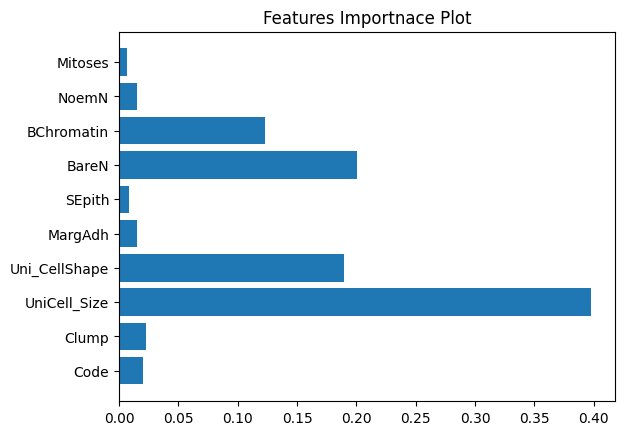

In [22]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.barh(df_imp["feature"],df_imp["importance"])
plt.title("Features Importnace Plot")
plt.show()